# Figure 4


## Setup


In [1]:
library(ggplot2)
library(patchwork)
library(cowplot)
library(dplyr)
library(tidyr)
library(scales)
library(ggrepel)
library(stringr)
library(yaml)
library(here)
library(grid)
library(forcats)
library(tibble)


Attaching package: ‘cowplot’




The following object is masked from ‘package:patchwork’:

    align_plots





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Styling and helpers


In [2]:
AXIS_TITLE_SIZE   <- 7
AXIS_LABEL_SIZE   <- 5.0
PLOT_TITLE_SIZE   <- 5.8
LEGEND_TEXT_SIZE  <- 5.0
LEGEND_TITLE_SIZE <- 6.0
FULL_MODEL_LABEL_SIZE <- 4.0
SMALL_PANEL_LABEL_SIZE <- 4.4
DOT_SIZE_RANGE    <- c(0.55, 1.65)
FILL_LIMITS       <- c(0, 15)
FILL_BREAKS       <- c(0, 5, 10, 15)

wrap_clean <- function(x, width = 28, max_width = 55) {
    stringr::str_wrap(stringr::str_trunc(stringr::str_squish(x), max_width), width = width)
}

theme_pub <- function(base_size = 7, base_line_size = 0.35) {
    theme_classic(base_size = base_size, base_family = 'Helvetica') %+replace%
    theme(
        plot.title        = element_text(size = PLOT_TITLE_SIZE, face = 'plain', hjust = 0.5,
                                         margin = margin(b = 2)),
        axis.line         = element_line(linewidth = base_line_size),
        axis.ticks        = element_line(linewidth = base_line_size),
        axis.text         = element_text(size = AXIS_LABEL_SIZE),
        axis.title        = element_text(size = AXIS_TITLE_SIZE, face = 'plain',
                                         margin = margin(t = 0, r = 0, b = 0, l = 0)),
        legend.text       = element_text(size = LEGEND_TEXT_SIZE),
        legend.title      = element_text(size = LEGEND_TITLE_SIZE, face = 'plain'),
        legend.key.size   = unit(3, 'mm'),
        legend.background = element_blank(),
        legend.key        = element_blank(),
        legend.position   = 'right',
        panel.grid        = element_blank(),
        strip.text        = element_text(size = PLOT_TITLE_SIZE, face = 'plain'),
        strip.background  = element_blank(),
        plot.margin       = unit(c(1, 2, 1, 1), 'mm')
    )
}

bubble_theme <- function(show_y_title = TRUE, extra_left_margin = 2) {
    theme_minimal(base_size = 6, base_family = 'Helvetica') +
        theme(
            plot.title         = element_text(size = PLOT_TITLE_SIZE, face = 'plain', hjust = 0.5,
                                              margin = margin(b = 1.5)),
            axis.title.y       = if (show_y_title) {
                element_text(size = AXIS_TITLE_SIZE, face = 'plain', margin = margin(r = extra_left_margin))
            } else { element_blank() },
            axis.title.x       = element_text(size = AXIS_TITLE_SIZE, face = 'plain', margin = margin(t = 0.2)),
            axis.text.x        = element_text(size = AXIS_LABEL_SIZE),
            axis.text.y        = element_text(size = AXIS_LABEL_SIZE, lineheight = 0.90),
            panel.grid.major.x = element_line(color = 'grey88', linewidth = 0.3),
            panel.grid.major.y = element_line(color = 'grey88', linewidth = 0.3),
            panel.grid.minor   = element_blank(),
            panel.border       = element_rect(color = 'grey70', fill = NA, linewidth = 0.45),
            legend.position    = 'none',
            plot.margin        = margin(2.0, 1.2, 2.2, 1.0)
        )
}

dot_fill_scale <- function(limits = FILL_LIMITS, breaks = FILL_BREAKS) {
    scale_fill_gradient(
        low = '#d9efe0', high = '#0b7d29', name = '-log10 FDR',
        limits = limits, breaks = breaks, oob = scales::squish
    )
}

legend_theme_shared <- function() {
    theme(
        legend.position      = 'top',
        legend.direction     = 'horizontal',
        legend.justification = 'center',
        legend.box.just      = 'center',
        legend.box           = 'horizontal',
        legend.spacing.x     = unit(2, 'mm'),
        legend.title         = element_text(size = LEGEND_TITLE_SIZE, family = 'Helvetica', face = 'plain', hjust = 0.5),
        legend.text          = element_text(size = LEGEND_TEXT_SIZE, family = 'Helvetica'),
        legend.margin        = margin(0, 0, 0, 0),
        legend.box.margin    = margin(0, 2, 0, 0),
        legend.background    = element_blank(),
        legend.key           = element_blank(),
        plot.margin          = margin(0, 0, 0, 0)
    )
}

make_colorbar <- function(limits = FILL_LIMITS, breaks = FILL_BREAKS) {
    legend_df <- tibble(x = seq_along(breaks), y = 1, neg_log10_fdr = breaks)
    ggplot(legend_df, aes(x, y, fill = neg_log10_fdr)) +
        geom_point(shape = 21, size = 0.1, colour = NA) +
        dot_fill_scale(limits, breaks) +
        guides(fill = guide_colourbar(title.position = 'top', title.hjust = 0.5, title.vjust = 0.5,
                                     barwidth = unit(2.1, 'cm'), barheight = unit(0.25, 'cm'),
                                     frame.colour = 'black', ticks.colour = 'black')) +
        theme_void(base_family = 'Helvetica') +
        legend_theme_shared()
}

make_inline_fdr_bar <- function(limits = FILL_LIMITS, breaks = FILL_BREAKS,
                                label_size = 1.75, tick_size = 1.55,
                                bar_height = 0.24) {
    span <- diff(limits)
    grad_df <- tibble(x = seq(limits[1], limits[2], length.out = 160),
                      y = 1, neg_log10_fdr = x)
    tick_df <- tibble(x = breaks, label = as.character(breaks))
    ggplot() +
        geom_tile(data = grad_df, aes(x = x, y = y, fill = neg_log10_fdr),
                  width = span / 160, height = bar_height) +
        annotate('rect', xmin = limits[1], xmax = limits[2],
                 ymin = 1 - bar_height / 2, ymax = 1 + bar_height / 2,
                 fill = NA, colour = 'black', linewidth = 0.28) +
        geom_segment(data = tick_df,
                     aes(x = x, xend = x,
                         y = 1 - bar_height / 2, yend = 1 - bar_height / 2 - 0.08),
                     linewidth = 0.25) +
        geom_text(data = tick_df, aes(x = x, y = 1 - bar_height / 2 - 0.22, label = label),
                  size = tick_size, family = 'Helvetica') +
        annotate('text', x = limits[1] - span * 0.12, y = 1,
                 label = '-log10 FDR', hjust = 1, vjust = 0.5,
                 size = label_size, family = 'Helvetica') +
        dot_fill_scale(limits, breaks) +
        coord_cartesian(xlim = c(limits[1] - span * 0.42, limits[2]),
                        ylim = c(0.54, 1.20), clip = 'off') +
        theme_void(base_family = 'Helvetica') +
        theme(legend.position = 'none', plot.margin = margin(0,0,0,0))
}

tight_limits <- function(x, lower = NULL, upper = NULL, pad_frac = 0.06, min_span = NULL) {
    vals <- x[is.finite(x)]
    if (length(vals) == 0) return(c(0, 1))
    lims <- range(vals)
    span <- diff(lims)
    if (!is.null(min_span) && span < min_span) {
        mid <- mean(lims); lims <- c(mid - min_span/2, mid + min_span/2); span <- diff(lims)
    }
    pad <- max(span * pad_frac, 1e-6); lims <- lims + c(-pad, pad)
    if (!is.null(lower)) lims[1] <- max(lower, lims[1])
    if (!is.null(upper)) lims[2] <- min(upper, lims[2])
    lims
}

tight_breaks <- function(lims, n = 3) {
    brks <- pretty(lims, n = n)
    brks[brks >= lims[1] & brks <= lims[2]]
}

clean_pathway <- function(x) {
    x <- str_squish(x)
    for (pfx in c('HALLMARK ', 'REACTOME REACTOME ', 'REACTOME ', 'KEGG ', 'WP ', 'PID ',
                  'GOBP ', 'GOCC ', 'GOMF ', 'C8 ', 'HE ', 'LIM ', 'SUN ')) {
        x <- ifelse(str_starts(toupper(x), pfx), str_sub(x, nchar(pfx) + 1), x)
    }
    str_squish(str_replace_all(x, '_', ' '))
}

placeholder_panel <- function(label) {
    ggplot() +
        annotate('rect', xmin=0, xmax=1, ymin=0, ymax=1, fill='grey94', color='grey75', linewidth=0.35) +
        annotate('text', x=0.5, y=0.5, label=label, size=2.1, color='grey45', fontface='plain',
                 hjust=0.5, vjust=0.5, lineheight=0.9) +
        theme_void(base_family='Helvetica') +
        theme(plot.margin = unit(c(1,2,1,1), 'mm'))
}

cfg       <- yaml::read_yaml(here('config.yaml'))
MODEL_COLORS <- setNames(unlist(cfg$MODEL_COLORS), names(cfg$MODEL_COLORS))
PANEL_DIR <- here('output/99_panels/fig4')
dir.create(PANEL_DIR, recursive = TRUE, showWarnings = FALSE)


## Row 1: Pathway and trait coverage


In [3]:

# Panel A: Hallmark pathway coverage
hall_cov_all <- read.csv(file.path(PANEL_DIR, 'hall_pathway_coverage.csv'), stringsAsFactors = FALSE)
model_cov_raw <- read.csv(file.path(PANEL_DIR, 'model_pathway_coverage.csv'), stringsAsFactors = FALSE)
DATASET_COLORS <- c(ARCHS4 = '#0072B2', recount2 = '#56B4E9', GTEx = '#009E73')
DATASET_LABELS <- c(GTEx = 'GTEx', recount2 = 'recount2', ARCHS4 = 'ARCHS4')

archs4_best_full <- hall_cov_all %>%
    dplyr::filter(coverage_pct == 100) %>%
    dplyr::arrange(dplyr::desc(n_sig_pathways), dplyr::desc(prop_pathway)) %>%
    dplyr::slice_head(n=1) %>%
    dplyr::transmute(name=name, dataset='ARCHS4', coverage_pct=coverage_pct, seed=seed,
                     n_samples=n_samples, n_input_pathways=n_input_pathways,
                     n_lvs=n_lvs, n_sig_pathways=n_sig_pathways, n_sig_lvs=n_sig_lvs,
                     prop_pathway=prop_pathway, prop_lv=prop_lv,
                     sig_pathway_per_lv=sig_pathway_per_lv, path=path)
model_cov <- model_cov_raw %>%
    dplyr::filter(dataset != 'ARCHS4') %>%
    dplyr::bind_rows(archs4_best_full) %>%
    dplyr::mutate(dataset = factor(dataset, levels = c('GTEx', 'recount2', 'ARCHS4')))

coverage_levels <- hall_cov_all %>%
    dplyr::filter(coverage_pct < 100) %>%
    dplyr::arrange(coverage_pct, n_samples) %>%
    dplyr::distinct(coverage_pct, n_samples) %>%
    dplyr::mutate(coverage_label = paste0(scales::comma(n_samples), '\n(', coverage_pct, '%)')) %>%
    dplyr::pull(coverage_label)

hall_cov <- hall_cov_all %>%
    dplyr::filter(coverage_pct < 100) %>%
    dplyr::mutate(
        coverage_label = paste0(scales::comma(n_samples), '\n(', coverage_pct, '%)'),
        coverage_label = factor(coverage_label, levels = coverage_levels),
        n_sig_pathways = round(prop_pathway * n_input_pathways)
    )

y_max_path <- max(max(hall_cov$n_sig_pathways), max(model_cov$n_sig_pathways)) * 1.30
path_yaxis <- scale_y_continuous(limits=c(0,y_max_path), breaks=seq(0, ceiling(y_max_path/250)*250, by=250),
                                  expand=expansion(mult=c(0,0.01)))

mean_df_A <- hall_cov %>%
    dplyr::group_by(coverage_label) %>%
    dplyr::summarise(mean_y=mean(n_sig_pathways),
                     mean_prop=mean(prop_pathway * 100),
                     max_y=max(n_sig_pathways), .groups='drop') %>%
    dplyr::mutate(label_y=max_y + y_max_path*0.018,
                  label=paste0(sprintf('%.0f', mean_y),'\n',sprintf('%.0f%%', mean_prop)))

plot_A1 <- ggplot(hall_cov, aes(x=coverage_label, y=n_sig_pathways)) +
    geom_boxplot(width=0.55, fill=scales::alpha('#0072B2',0.70), colour='black',
                 linewidth=0.28, outlier.shape=NA) +
    geom_jitter(width=0.055, size=0.55, shape=21, fill='white',
                colour='#333333', stroke=0.18, alpha=0.88) +
    stat_summary(fun=mean, geom='point', shape=23, size=0.9,
                 fill='white', colour='black', stroke=0.25) +
    geom_text(data=mean_df_A, aes(x=coverage_label,y=label_y,label=label),
              size=1.45, fontface='bold', vjust=0) +
    path_yaxis + coord_cartesian(clip='off') +
    labs(x='Number of samples (%)', y='Recovered pathways', title='Sample size') +
    theme_pub() +
    theme(axis.text.x=element_text(size=AXIS_LABEL_SIZE, lineheight=0.86),
          panel.grid.major.y=element_line(color='grey90', linewidth=0.28),
          plot.margin=unit(c(5,1,2,3),'mm'))

model_cov_lab <- model_cov %>%
    dplyr::mutate(label_y = n_sig_pathways + y_max_path*0.045,
                  label   = paste0(n_sig_pathways,'\n',sprintf('%.0f%%',prop_pathway*100)))

a2_xlabels <- setNames(
    paste0(as.character(model_cov_lab$dataset), '\n', scales::comma(model_cov_lab$n_samples)),
    as.character(model_cov_lab$dataset)
)

plot_A2 <- ggplot(model_cov_lab, aes(x=dataset,y=n_sig_pathways,fill=dataset)) +
    geom_point(shape=23, size=2.65, colour='black', stroke=0.65) +
    geom_text(aes(y=label_y,label=label),
              size=1.28, fontface='bold', lineheight=0.84, vjust=0, colour='black') +
    scale_x_discrete(labels=a2_xlabels, expand=expansion(add=0.42)) +
    scale_fill_manual(values=DATASET_COLORS, guide='none') +
    path_yaxis + coord_cartesian(clip='off') +
    labs(x=NULL, y=NULL, title='Full models') +
    theme_pub() +
    theme(plot.title=element_text(size=5.3, hjust=0.5),
          axis.text.x=element_text(angle=35,hjust=1,size=FULL_MODEL_LABEL_SIZE),
          axis.text.y=element_blank(), axis.ticks.y=element_blank(),
          panel.grid.major.y=element_line(color='grey90', linewidth=0.28),
          axis.line.y=element_blank(), plot.margin=unit(c(5,2,2,0),'mm'))

plot_A_core <- plot_grid(plot_A1, plot_A2, ncol=2, rel_widths=c(3,1), align='h', axis='tb')
plot_A <- plot_grid(
    ggdraw() + draw_label('Pathway coverage', fontface='bold', fontfamily='Helvetica', size=7.0),
    plot_A_core, ncol=1, rel_heights=c(0.10,1)
)


In [4]:

# ── Panel B already defined in cell fig4-panels-CD by user ───────────────
# (plot_A = panel_A composite built above; plot_B = panel_B composite built in the CD cell)
# This cell is kept as placeholder
invisible(NULL)


In [5]:

# Panel B: Trait coverage
trait_cov   <- read.csv(file.path(PANEL_DIR,'hall_trait_coverage.csv'), stringsAsFactors=FALSE)
trait_model <- read.csv(file.path(PANEL_DIR,'trait_model_coverage.csv'), stringsAsFactors=FALSE)

get_trait_coverage_from_summary <- function(path, dataset, n_samples, total_traits, seed = NA_integer_,
                                            fdr_cutoff = 0.05) {
    full_path <- here(path)
    if (!file.exists(full_path)) stop('File not found: ', full_path)
    summary_df <- readr::read_tsv(full_path, show_col_types = FALSE, progress = FALSE)
    sig_df <- summary_df %>% dplyr::filter(fdr < fdr_cutoff)
    n_lvs <- dplyr::n_distinct(summary_df$lv)
    n_sig_traits <- dplyr::n_distinct(sig_df$phenotype)
    n_sig_lvs <- dplyr::n_distinct(sig_df$lv)
    data.frame(
        n_rows = nrow(summary_df),
        n_sig_rows = nrow(sig_df),
        n_phenotypes = total_traits,
        n_lvs = n_lvs,
        n_sig_traits = n_sig_traits,
        n_sig_lvs = n_sig_lvs,
        prop_trait = n_sig_traits / total_traits,
        prop_lv = n_sig_lvs / n_lvs,
        dataset = dataset,
        n_samples = n_samples,
        nominal_n_lvs = n_lvs,
        seed = seed,
        path = path,
        stringsAsFactors = FALSE
    )
}

archs4_trait_n_samples <- trait_model %>%
    dplyr::filter(dataset == 'ARCHS4') %>%
    dplyr::pull(n_samples) %>%
    dplyr::first(default = 605614)

archs4_trait_full <- do.call(rbind, lapply(1:3, function(seed) {
    get_trait_coverage_from_summary(
        file.path('output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100',
                  paste0('hall_coverage_rs100_seed_', seed), 'gls-summary-phenomexcan.tsv.gz'),
        dataset = 'ARCHS4', n_samples = archs4_trait_n_samples,
        total_traits = dplyr::first(trait_cov$n_phenotypes), seed = seed
    )
}))

archs4_best_trait_full <- archs4_trait_full %>%
    dplyr::arrange(dplyr::desc(n_sig_traits), dplyr::desc(prop_trait)) %>%
    dplyr::slice_head(n = 1)

trait_model <- trait_model %>%
    dplyr::filter(dataset != 'ARCHS4') %>%
    dplyr::bind_rows(archs4_best_trait_full)

write.csv(trait_model, file.path(PANEL_DIR, 'trait_model_coverage.csv'), row.names = FALSE)

trait_coverage_levels <- trait_cov %>%
    dplyr::arrange(coverage_pct, n_samples) %>%
    dplyr::distinct(coverage_pct, n_samples) %>%
    dplyr::mutate(coverage_label = paste0(scales::comma(n_samples), '\n(', coverage_pct, '%)')) %>%
    dplyr::pull(coverage_label)

trait_cov <- trait_cov %>%
    dplyr::mutate(
        coverage_label = paste0(scales::comma(n_samples), '\n(', coverage_pct, '%)'),
        coverage_label = factor(coverage_label, levels = trait_coverage_levels)
    )
trait_model$dataset  <- factor(trait_model$dataset, levels=c('GTEx','recount2','ARCHS4'))

y_max_trait <- max(max(trait_cov$n_sig_traits), max(trait_model$n_sig_traits)) * 1.30
trait_yaxis <- scale_y_continuous(limits=c(0,y_max_trait),
                                   breaks=seq(0, ceiling(y_max_trait/250)*250, by=250),
                                   expand=expansion(mult=c(0,0.01)))

mean_df_B <- trait_cov %>%
    dplyr::group_by(coverage_label) %>%
    dplyr::summarise(mean_y=mean(n_sig_traits),
                     mean_prop=mean(prop_trait * 100),
                     max_y=max(n_sig_traits), .groups='drop') %>%
    dplyr::mutate(label_y=max_y + y_max_trait*0.018,
                  label=paste0(sprintf('%.0f', mean_y),'\n',sprintf('%.0f%%', mean_prop)))

plot_B1 <- ggplot(trait_cov, aes(x=coverage_label, y=n_sig_traits)) +
    geom_boxplot(width=0.55, fill=scales::alpha('#756BB1',0.76), colour='black',
                 linewidth=0.28, outlier.shape=NA) +
    geom_jitter(width=0.055, size=0.55, shape=21, fill='white',
                colour='#333333', stroke=0.18, alpha=0.88) +
    stat_summary(fun=mean, geom='point', shape=23, size=0.9,
                 fill='white', colour='black', stroke=0.25) +
    geom_text(data=mean_df_B, aes(x=coverage_label,y=label_y,label=label),
              size=1.45, fontface='bold', vjust=0) +
    trait_yaxis + coord_cartesian(clip='off') +
    labs(x='Number of samples (%)', y='Recovered genetic traits', title='Sample size') +
    theme_pub() +
    theme(axis.text.x=element_text(size=AXIS_LABEL_SIZE, lineheight=0.86),
          panel.grid.major.y=element_line(color='grey90', linewidth=0.28),
          plot.margin=unit(c(5,1,2,3),'mm'))

trait_model_lab <- trait_model %>%
    dplyr::mutate(label_y=n_sig_traits+y_max_trait*0.045,
                  label=paste0(format(n_sig_traits,big.mark=','),'\n',
                               sprintf('%.0f%%',prop_trait*100)))

b2_xlabels <- setNames(
    paste0(as.character(trait_model_lab$dataset), '\n', scales::comma(trait_model_lab$n_samples)),
    as.character(trait_model_lab$dataset)
)

plot_B2 <- ggplot(trait_model_lab, aes(x=dataset,y=n_sig_traits,fill=dataset)) +
    geom_point(shape=23, size=2.65, colour='black', stroke=0.65) +
    geom_text(aes(y=label_y,label=label),
              size=1.28, fontface='bold', lineheight=0.84, vjust=0, colour='black') +
    scale_x_discrete(labels=b2_xlabels, expand=expansion(add=0.42)) +
    scale_fill_manual(values=DATASET_COLORS, guide='none') +
    trait_yaxis + coord_cartesian(clip='off') +
    labs(x=NULL, y=NULL, title='Full models') +
    theme_pub() +
    theme(plot.title=element_text(size=5.3, hjust=0.5),
          axis.text.x=element_text(angle=35,hjust=1,size=FULL_MODEL_LABEL_SIZE),
          axis.text.y=element_blank(), axis.ticks.y=element_blank(),
          panel.grid.major.y=element_line(color='grey90', linewidth=0.28),
          axis.line.y=element_blank(), plot.margin=unit(c(5,2,2,0),'mm'))

plot_B_core <- plot_grid(plot_B1, plot_B2, ncol=2,
                         rel_widths=c(3,1), align='h', axis='tb')
plot_B_composite <- plot_grid(
    ggdraw() + draw_label('Trait coverage', fontface='bold', fontfamily='Helvetica', size=7.0),
    plot_B_core, ncol=1, rel_heights=c(0.10,1)
)


## Row 2: GTEx projection and drug-disease association


In [6]:
# Panel C: GTEx tissue pathway dotplot
# Panel D: Pseudobulk LV-proportion scatter 2x2

plot_C <- NULL
plot_D <- NULL

# ── GTEx ─────────────────────────────────────────────────────────────────────
bio_raw    <- read.csv(file.path(PANEL_DIR,'gtex_tissue_lv_biology.csv'),  stringsAsFactors=FALSE)
top_lv_raw <- read.csv(file.path(PANEL_DIR,'gtex_top_lvs_per_tissue.csv'), stringsAsFactors=FALSE)

BEST_PATHWAY_GTEX <- c(
    'Brain'    = 'REACTOME_REACTOME_GLUTAMATE_NEUROTRANSMITTER_RELEASE_CYCLE',
    'Muscle'   = 'REACTOME_REACTOME_STRIATED_MUSCLE_CONTRACTION',
    'Heart'    = 'C8_CUI_DEVELOPING_HEART_C2_CARDIOMYOCYTE',
    'Liver'    = 'C8_AIZARANI_LIVER_C17_HEPATOCYTES_3',
    'Testis'   = 'GOCC_GOCC_AXONEMAL_DOUBLET_MICROTUBULE',
    'Prostate' = 'REACTOME_REACTOME_ACTIVATED_PKN1_STIMULATES_TRANSCRIPTION_OF_AR_ANDROGEN_RECEPTOR_REGULATED_GENES_KLK2_AND_KLK3',
    'Pituitary'= 'REACTOME_REACTOME_CYTOCHROME_P450_ARRANGED_BY_SUBSTRATE_TYPE',
    'Blood'    = 'REACTOME_REACTOME_SIGNALING_BY_FLT3_ITD_AND_TKD_MUTANTS',
    'Lung'     = 'C8_HE_LIM_SUN_FETAL_LUNG_C1_LATE_TIP_CELL',
    'Nerve'    = 'C8_DESCARTES_FETAL_ADRENAL_SCHWANN_CELLS',
    'Spleen'   = 'GOCC_GOCC_MHC_CLASS_II_PROTEIN_COMPLEX',
    'Stomach'  = 'C8_BUSSLINGER_GASTRIC_IMMATURE_PIT_CELLS'
)
TISSUE_ORDER <- names(BEST_PATHWAY_GTEX)

top_lv_ord <- top_lv_raw %>%
    dplyr::filter(tissue %in% TISSUE_ORDER) %>%
    dplyr::arrange(tissue, dplyr::desc(mean_shap)) %>%
    dplyr::group_by(tissue) %>%
    dplyr::mutate(lv_shap_rank = dplyr::row_number()) %>%
    dplyr::ungroup()

gtex_1pw <- top_lv_ord %>%
    dplyr::inner_join(bio_raw, by = c('tissue','LV')) %>%
    dplyr::filter(pathway != 'NO_SIGNIFICANT_PATHWAY', !is.na(FDR), FDR < 0.05) %>%
    dplyr::mutate(neg_log10_fdr = pmin(-log10(pmax(FDR, 1e-20)), 15)) %>%
    dplyr::rowwise() %>%
    dplyr::filter(tissue %in% names(BEST_PATHWAY_GTEX) &
                  pathway == BEST_PATHWAY_GTEX[tissue]) %>%
    dplyr::ungroup() %>%
    dplyr::distinct(tissue, .keep_all = TRUE) %>%
    dplyr::arrange(match(tissue, rev(TISSUE_ORDER))) %>%
    dplyr::mutate(
        y_label = dplyr::case_when(
            tissue == 'Brain'    ~ paste0('Brain', '\n', 'Glutamate release'),
            tissue == 'Muscle'   ~ paste0('Muscle', '\n', 'Striated contraction'),
            tissue == 'Heart'    ~ paste0('Heart', '\n', 'Cardiomyocyte'),
            tissue == 'Liver'    ~ paste0('Liver', '\n', 'Hepatocytes'),
            tissue == 'Testis'   ~ paste0('Testis', '\n', 'Axonemal microtubule'),
            tissue == 'Prostate' ~ paste0('Prostate', '\n', 'AR/KLK2-3 signaling'),
            tissue == 'Pituitary'~ paste0('Pituitary', '\n', 'CYP450 enzymes'),
            tissue == 'Blood'    ~ paste0('Blood', '\n', 'FLT3 signaling'),
            tissue == 'Lung'     ~ paste0('Lung', '\n', 'Late tip cell'),
            tissue == 'Nerve'    ~ paste0('Nerve', '\n', 'Schwann cells'),
            tissue == 'Spleen'   ~ paste0('Spleen', '\n', 'MHC-II complex'),
            tissue == 'Stomach'  ~ paste0('Stomach', '\n', 'Gastric pit cells'),
            TRUE ~ tissue
        )
    )

auc_lims <- tight_limits(gtex_1pw$AUC, lower=0.75, upper=1.0, pad_frac=0.02, min_span=0.10)
auc_brks <- tight_breaks(auc_lims, n=3)

p_gtex_core <- {
    df <- gtex_1pw %>% dplyr::mutate(y_pos = rev(seq_len(dplyr::n())))
    ggplot(df, aes(x=AUC, y=y_pos)) +
        geom_hline(aes(yintercept=y_pos), colour='grey93', linewidth=0.20) +
        geom_point(aes(size=AUC, fill=neg_log10_fdr), shape=21, colour='#333333', stroke=0.28) +
        scale_x_continuous(limits=auc_lims, breaks=auc_brks,
                           labels=scales::label_number(accuracy=0.01, trim=TRUE),
                           expand=expansion(mult=c(0.05,0.10))) +
        scale_y_continuous(limits=c(0.5,nrow(df)+0.5), breaks=df$y_pos,
                           labels=df$y_label, expand=c(0,0)) +
        scale_size_continuous(limits=auc_lims, range=c(0.8,2.2), guide='none') +
        dot_fill_scale(c(0,15), c(0,5,10,15)) +
        labs(x='AUC', y=NULL) +
        bubble_theme(show_y_title=FALSE) +
        theme(axis.text.y  = element_text(size=4.0, lineheight=0.88, family='sans'),
              axis.text.x  = element_text(size=4.5, family='sans'),
              axis.title.x = element_text(size=5.2, family='sans'),
              legend.position='none')
}

plot_E_legend <- make_inline_fdr_bar(c(0,15), c(0,5,10,15),
                                     label_size=1.55, tick_size=1.35, bar_height=0.22)
plot_C_header <- plot_grid(
    ggdraw() + draw_label('GTEx tissue pathways', x=0, hjust=0,
                          fontfamily='sans', fontface='plain', size=5.6),
    plot_E_legend, ncol=2, rel_widths=c(0.47,0.53)
)
plot_C <- plot_grid(plot_C_header, p_gtex_core, ncol=1, rel_heights=c(0.10,1))

# ── Pseudobulk ────────────────────────────────────────────────────────────────
clean_pb_pw <- function(x) {
    for (pfx in c('HALLMARK_','HALL_HALLMARK_','REACTOME_REACTOME_','REACTOME_',
                  'GOBP_GOBP_','GOBP_','GOCC_GOCC_','GOCC_')) {
        if (startsWith(toupper(x), pfx)) { x <- substr(x, nchar(pfx)+1, nchar(x)); break }
    }
    tools::toTitleCase(tolower(gsub('_',' ',stringr::str_squish(x))))
}
EXAMPLES <- list(
    list(dataset='Brain_Mathys2023', ct='Ast',       lv='LV831',
         disp_ct='Astrocytes',          pw_disp='Notch Signaling'),
    list(dataset='Brain_Mathys2023', ct='Mic',       lv='LV1702',
         disp_ct='Microglia',           pw_disp='Traf6/IRF7 Activation'),
    list(dataset='PBMC_1k1k',        ct='B_cell',    lv='LV80',
         disp_ct='B cells',            pw_disp='CD22 BCR Regulation'),
    list(dataset='PBMC_1k1k',        ct='CD14_Mono', lv='LV12',
         disp_ct='Classical monocytes', pw_disp='TNFα / NF-κB')
)
ds_cache <- list()
for (ex in EXAMPLES) {
    if (is.null(ds_cache[[ex$dataset]])) {
        proj  <- data.table::fread(
            file.path(here('output','03_model_biology','00_archs4','04_pseudobulk',
                           ex$dataset,'projection.csv')), data.table=FALSE)
        rownames(proj) <- proj[[1]]; proj[[1]] <- NULL
        truth <- read.csv(
            file.path(here('data','pseudobulk',ex$dataset,'truthFrac_v0.csv')),
            row.names=1, check.names=FALSE)
        shared <- intersect(colnames(proj), rownames(truth))
        ds_cache[[ex$dataset]] <- list(proj=proj[,shared,drop=FALSE],
                                       truth=truth[shared,,drop=FALSE])
    }
}
scat_plots <- vector('list', 4)
for (i in seq_along(EXAMPLES)) {
    ex  <- EXAMPLES[[i]]
    dat <- ds_cache[[ex$dataset]]
    x   <- as.numeric(dat$truth[[ex$ct]])
    y   <- as.numeric(dat$proj[ex$lv,])
    r2 <- cor(x, y, method='pearson')^2
    fit  <- lm(y~x, data=data.frame(x=x,y=y))
    xr   <- seq(min(x),max(x),length.out=80)
    pred_df <- data.frame(x=xr, y=predict(fit, data.frame(x=xr)))
    scat_plots[[i]] <- ggplot(data.frame(x=x,y=y), aes(x=x,y=y)) +
        geom_point(alpha=0.38, size=0.90, colour='#555555', stroke=0) +
        geom_line(data=pred_df, aes(x=x,y=y), colour='#0072B2', linewidth=0.80) +
        annotate('text', x=Inf, y=-Inf,
                 label=paste0('R^2==', sprintf('%.2f', r2)),
                 hjust=1.08, vjust=-0.25, size=2.30, family='sans',
                 colour='#111111', parse=TRUE) +
        labs(title=paste0(ex$disp_ct,'\n',ex$pw_disp), x=NULL, y=NULL) +
        theme_minimal(base_size=7, base_family='sans') +
        theme(plot.title=element_text(size=6.2, hjust=0.5, lineheight=0.90, margin=margin(b=1.5)),
              axis.text=element_text(size=5.2), axis.ticks=element_line(linewidth=0.3, colour='grey60'),
              panel.grid.major=element_line(colour='grey90', linewidth=0.25),
              panel.grid.minor=element_blank(),
              panel.border=element_rect(colour='grey70', fill=NA, linewidth=0.40),
              plot.margin=margin(2,3,2,3))
}
pb_inner  <- plot_grid(scat_plots[[1]],scat_plots[[2]],scat_plots[[3]],scat_plots[[4]],
                       nrow=2, ncol=2, align='hv')
shared_x  <- ggdraw() + draw_label('Cell-type proportion', fontfamily='sans', size=6.0, hjust=0.5)
shared_y  <- ggdraw() + draw_label('LV score', fontfamily='sans', size=6.0, angle=90, hjust=0.5)
pb_with_x <- plot_grid(pb_inner, shared_x, ncol=1, rel_heights=c(1,0.06))
pb_grid   <- plot_grid(shared_y, pb_with_x, ncol=2, rel_widths=c(0.05,1))

plot_D <- plot_grid(
    ggdraw() + draw_label('Pseudobulk', x=0.5, hjust=0.5,
                          fontfamily='sans', fontface='plain', size=5.6),
    pb_grid, ncol=1, rel_heights=c(0.05,1)
)
plot_E <- plot_C   # keep plot_E as alias for assembly compatibility

In [7]:
# Panel E: Drug-disease — horizontal barplots with colors + proper line breaks
plot_F <- NULL

perf <- read.csv(file.path(PANEL_DIR,'drug_disease_performance_v2.csv'), stringsAsFactors=FALSE)
grp  <- read.csv(file.path(PANEL_DIR,'drug_disease_lv_groups.csv'),      stringsAsFactors=FALSE)
positive_rate <- 0.757

# ── Color palettes ────────────────────────────────────────────────────────────
METHOD_PAL <- c(
    'ARCHS4 LV-based'   = '#0072B2',
    'GTEx LV-based'     = '#009E73',
    'recount2 LV-based' = '#D55E00',
    'Gene-based'        = '#777777',
    'Random'            = '#CCCCCC'
)
GROUP_PAL <- c(
    'Pathway + Trait' = '#0072B2',
    'Pathway only'    = '#56B4E9',
    'Trait only'      = '#E69F00',
    'Neither'         = '#BBBBBB',
    'Random'          = '#CCCCCC'
)

# ── Label line-break lookup (use paste0 to guarantee real newline) ────────────
LB <- list(
    'ARCHS4 LV-based'   = paste0('ARCHS4',    '\n', 'LV-based'),
    'GTEx LV-based'     = paste0('GTEx',       '\n', 'LV-based'),
    'recount2 LV-based' = paste0('recount2',   '\n', 'LV-based'),
    'Gene-based'        = 'Gene-based',
    'Random'            = 'Random',
    'Pathway + Trait'   = paste0('Pathway +',  '\n', 'Trait'),
    'Pathway only'      = paste0('Pathway',    '\n', 'only'),
    'Trait only'        = paste0('Trait',      '\n', 'only'),
    'Neither'           = 'Neither'
)
apply_lb <- function(x) {
    vapply(x, function(v) if (!is.null(LB[[v]])) LB[[v]] else v, character(1))
}

# Remap color palettes to use line-break labels
method_pal_lb <- setNames(METHOD_PAL, apply_lb(names(METHOD_PAL)))
group_pal_lb  <- setNames(GROUP_PAL,  apply_lb(names(GROUP_PAL)))

# ── Bar builder ───────────────────────────────────────────────────────────────
make_dd_bar <- function(df, val_col, lo_col, hi_col, label_col,
                         color_pal, xlabel, xlim, title) {
    df[[label_col]] <- apply_lb(as.character(df[[label_col]]))
    df <- df[order(df[[val_col]], decreasing=FALSE), ]
    df[[label_col]] <- factor(df[[label_col]], levels=df[[label_col]])

    ggplot(df, aes(x=.data[[val_col]], y=.data[[label_col]],
                   fill=.data[[label_col]])) +
        geom_col(width=0.55, colour=NA) +
        geom_errorbarh(aes(xmin=.data[[lo_col]], xmax=.data[[hi_col]]),
                       height=0.18, linewidth=0.55, colour='#333333') +
        geom_text(aes(x=pmin(.data[[hi_col]] + diff(xlim)*0.022, xlim[2]-diff(xlim)*0.01),
                      label=sprintf('%.3f', .data[[val_col]])),
                  hjust=0, size=1.70, family='sans', colour='#111111') +
        scale_x_continuous(limits=xlim, breaks=seq(0,1,by=0.2),
                           expand=expansion(mult=c(0,0.10))) +
        scale_fill_manual(values=color_pal, guide='none') +
        labs(x=xlabel, y=NULL, title=title) +
        theme_minimal(base_size=5.5, base_family='sans') +
        theme(
            plot.title         = element_text(size=5.2, hjust=0.5, face='plain',
                                              margin=margin(b=1)),
            axis.text.y        = element_text(size=4.2, colour='#111111', lineheight=0.82),
            axis.text.x        = element_text(size=3.8, colour='#333333'),
            axis.title.x       = element_text(size=4.6, margin=margin(t=1)),
            axis.ticks.x       = element_line(linewidth=0.3, colour='grey60'),
            axis.ticks.y       = element_blank(),
            panel.grid.major.x = element_line(colour='grey82', linewidth=0.35),
            panel.grid.major.y = element_blank(),
            panel.grid.minor   = element_blank(),
            panel.border       = element_blank(),
            axis.line.x        = element_line(colour='grey50', linewidth=0.35),
            plot.margin        = margin(1,2,1,1)
        )
}

# ── Plot 1: method comparison ─────────────────────────────────────────────────
perf_plot <- perf %>%
    dplyr::filter(method %in% names(METHOD_PAL))

p1_auroc <- make_dd_bar(perf_plot,'auroc','auroc_lo','auroc_hi','method',
                         method_pal_lb,'AUROC',c(0,1),'AUROC')
p1_auprc <- make_dd_bar(perf_plot,'auprc','auprc_lo','auprc_hi','method',
                         method_pal_lb,'AUPRC',c(0,1),'AUPRC')

plot_F1 <- plot_grid(
    ggdraw() + draw_label('Drug-disease prediction', x=0.5, hjust=0.5,
                          fontfamily='sans', fontface='plain', size=6.2),
    plot_grid(p1_auroc, p1_auprc, ncol=2, align='h', axis='tb',
              rel_widths=c(1,1)),
    ncol=1, rel_heights=c(0.09,1)
)

# ── Plot 2: ARCHS4 LV groups + Random ────────────────────────────────────────
random_row <- perf %>%
    dplyr::filter(method=='Random') %>%
    dplyr::transmute(group='Random', threshold='random',
                     auroc, auroc_lo, auroc_hi, auprc, auprc_lo, auprc_hi,
                     n=NA_integer_, n_pos=NA_integer_)
grp_all <- dplyr::bind_rows(grp, random_row) %>%
    dplyr::filter(group %in% names(GROUP_PAL))

p2_auroc <- make_dd_bar(grp_all,'auroc','auroc_lo','auroc_hi','group',
                         group_pal_lb,'AUROC',c(0,1),'')
p2_auprc <- make_dd_bar(grp_all,'auprc','auprc_lo','auprc_hi','group',
                         group_pal_lb,'AUPRC',c(0,1),'')

plot_F2 <- plot_grid(p2_auroc, p2_auprc, ncol=2, align='h', axis='tb',
                     rel_widths=c(1,1))

plot_F <- plot_grid(plot_F1, plot_F2, ncol=1, rel_heights=c(1,0.90))


Warning message:
“`geom_errobarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”


`height` was translated to `width`.


`height` was translated to `width`.


`height` was translated to `width`.


`height` was translated to `width`.


## Row 3: External projections into ARCHS4


In [8]:

# Panel E: LV702 significant pathways, traits, and ORA
make_lv_ora_plot <- function(df, title, top_n=6, x_lab='Fold enrichment') {
    if (is.null(df) || nrow(df)==0 || !any(df$p.adjust < 0.05, na.rm=TRUE)) {
        return(placeholder_panel(paste0(title, '\n(no significant hits)')))
    }
    df <- df %>%
        dplyr::filter(p.adjust < 0.05) %>%
        dplyr::mutate(
            gene_ratio  = sapply(strsplit(GeneRatio,'/'), function(s) as.numeric(s[1])/as.numeric(s[2])),
            bg_ratio    = sapply(strsplit(BgRatio,  '/'), function(s) as.numeric(s[1])/as.numeric(s[2])),
            fold_enrich = gene_ratio / bg_ratio,
            neg_log_fdr = pmin(-log10(pmax(p.adjust,1e-20)), 10),
            term_label  = wrap_clean(clean_pathway(ID), width=18, max_width=42)
        ) %>%
        dplyr::arrange(dplyr::desc(neg_log_fdr), dplyr::desc(fold_enrich)) %>%
        dplyr::slice_head(n=top_n) %>%
        dplyr::arrange(fold_enrich) %>%
        dplyr::mutate(term_label = factor(term_label, levels=unique(term_label)))

    x_lims <- tight_limits(df$fold_enrich, lower=0, pad_frac=0.04, min_span=1)

    ggplot(df, aes(x=fold_enrich, y=term_label)) +
        geom_segment(aes(x=0,xend=fold_enrich,y=term_label,yend=term_label),
                     colour='grey80', linewidth=0.32, linetype='dotted') +
        geom_point(aes(size=Count, fill=neg_log_fdr), shape=21, colour='#333333', stroke=0.32) +
        scale_fill_gradient(low='#e5f5e0', high='#00441b', name='-log10 FDR',
                            limits=c(0,10), oob=scales::squish) +
        scale_size_continuous(range=c(0.65,2.25), guide='none') +
        scale_x_continuous(limits=x_lims, breaks=tight_breaks(x_lims,3),
                           labels=label_number(accuracy=0.1,trim=TRUE),
                           expand=expansion(mult=c(0,0.08))) +
        labs(x=x_lab, y=NULL, title=title) +
        bubble_theme(show_y_title=FALSE) +
        theme(axis.text.x   = element_text(size=3.7),
              axis.text.y   = element_text(size=3.6, lineheight=0.82),
              axis.title.x  = element_text(size=4.9),
              plot.title    = element_text(size=4.6, hjust=0.5, margin=margin(b=0.6)),
              legend.position='none',
              plot.margin    = margin(1,2,1,2))
}

lv702_paths <- read.csv(file.path(PANEL_DIR,'lv702_pathways.csv'), stringsAsFactors=FALSE)
lv702_p_top <- lv702_paths %>%
    dplyr::filter(AUC > 0.5, FDR < 0.05) %>%
    dplyr::mutate(
        pathway_label = tools::toTitleCase(tolower(pathway_clean)),
        pathway_label = wrap_clean(pathway_label, width=18, max_width=42),
        neg_log10_fdr = pmin(-log10(pmax(FDR,1e-20)),10)
    ) %>%
    dplyr::arrange(AUC)

if (nrow(lv702_p_top) == 0) {
    p_lv702_paths <- placeholder_panel('CLAMP pathway\n(no significant hits)')
} else {
    lv702_p_top$pathway_label <- factor(lv702_p_top$pathway_label, levels=unique(lv702_p_top$pathway_label))
    x_p <- tight_limits(lv702_p_top$AUC, lower=0.4, upper=1.0, pad_frac=0.04, min_span=0.2)
    p_lv702_paths <- ggplot(lv702_p_top, aes(x=AUC, y=pathway_label)) +
        geom_segment(aes(x=0.4,xend=AUC,y=pathway_label,yend=pathway_label),
                     colour='grey80', linewidth=0.32, linetype='dotted') +
        geom_point(aes(size=AUC, fill=neg_log10_fdr), shape=21, colour='#333333', stroke=0.32) +
        scale_x_continuous(limits=x_p, labels=label_number(accuracy=0.01,trim=TRUE),
                           breaks=tight_breaks(x_p,3), expand=expansion(mult=c(0.04,0.12))) +
        scale_size_continuous(limits=x_p, range=c(0.85,2.35), guide='none') +
        scale_fill_gradient(low='#d9efe0', high='#0b7d29', name='-log10 FDR',
                            limits=c(0,10), breaks=c(0,5,10), oob=scales::squish) +
        labs(x='AUC', y=NULL, title='CLAMP pathway') +
        bubble_theme(show_y_title=FALSE) +
        theme(axis.text.x=element_text(size=3.7),
              axis.text.y=element_text(size=3.6,lineheight=0.82),
              axis.title.x=element_text(size=4.9),
              plot.title=element_text(size=4.6, hjust=0.5, margin=margin(b=0.6)),
              legend.position='none', plot.margin=margin(1,2,1,2))
}

lv702_traits <- read.csv(file.path(PANEL_DIR,'lv702_traits.csv'), stringsAsFactors=FALSE)
tc <- if ('phenotype_label' %in% names(lv702_traits)) 'phenotype_label' else names(lv702_traits)[2]
lv702_traits <- lv702_traits %>%
    dplyr::filter(fdr < 0.05) %>%
    dplyr::mutate(
        trait_label = .data[[tc]],
        trait_label = stringr::str_replace(trait_label, '^Illnesses of mother:\\s*', 'Mother: '),
        trait_label = stringr::str_replace(trait_label, '^Illnesses of father:\\s*', 'Father: '),
        trait_label = wrap_clean(trait_label, width=22, max_width=42),
        neg_log10_fdr = pmin(-log10(pmax(fdr,1e-20)),10)
    ) %>%
    dplyr::arrange(neg_log10_fdr)

if (nrow(lv702_traits) == 0) {
    p_lv702_traits <- placeholder_panel('Traits\n(no significant hits)')
} else {
    lv702_traits$trait_label <- factor(lv702_traits$trait_label, levels=unique(lv702_traits$trait_label))
    x_t <- tight_limits(lv702_traits$neg_log10_fdr, lower=0, pad_frac=0.06, min_span=1.5)
    p_lv702_traits <- ggplot(lv702_traits, aes(x=neg_log10_fdr, y=trait_label)) +
        geom_segment(aes(x=0,xend=neg_log10_fdr,y=trait_label,yend=trait_label),
                     colour='grey80', linewidth=0.32, linetype='dotted') +
        geom_point(aes(size=neg_log10_fdr, fill=neg_log10_fdr), shape=21, colour='#333333', stroke=0.3) +
        scale_x_continuous(limits=x_t, labels=label_number(accuracy=0.1,trim=TRUE),
                           breaks=tight_breaks(x_t,3), expand=expansion(mult=c(0.04,0.18))) +
        scale_size_continuous(limits=x_t, range=c(0.85,2.35), guide='none') +
        scale_fill_gradient(low='#d9efe0', high='#0b7d29', name='-log10 FDR',
                            limits=c(0,10), oob=scales::squish) +
        labs(x='-log10 FDR', y=NULL, title='Traits') +
        bubble_theme(show_y_title=FALSE) +
        theme(axis.text.x=element_text(size=3.7),
              axis.text.y=element_text(size=3.4,lineheight=0.88),
              axis.title.x=element_text(size=4.9),
              plot.title=element_text(size=4.6, hjust=0.5, margin=margin(b=0.6)),
              legend.position='none', plot.margin=margin(1,2,1,2))
}

ora_archs4_df <- tryCatch(read.csv(file.path(PANEL_DIR,'lv702_ora_archs4.csv'), stringsAsFactors=FALSE), error=function(e) NULL)
p_lv702_archs4 <- make_lv_ora_plot(ora_archs4_df, 'ARCHS4 cell-line', top_n=3)

ora_wiki_df <- tryCatch(read.csv(file.path(PANEL_DIR,'lv702_ora_wiki.csv'), stringsAsFactors=FALSE), error=function(e) NULL)
p_lv702_wiki <- make_lv_ora_plot(ora_wiki_df, 'WikiPathways', top_n=3)

count_ora_rows <- function(df, top_n=3) {
    if (is.null(df) || nrow(df)==0 || !'p.adjust' %in% names(df)) return(1)
    n <- df %>% dplyr::filter(p.adjust < 0.05) %>% dplyr::slice_head(n=top_n) %>% nrow()
    max(1, n)
}
e_plot_heights <- c(
    1 + max(1, nrow(lv702_p_top)),
    1 + max(1, nrow(lv702_traits)),
    1 + count_ora_rows(ora_archs4_df, 3),
    1 + count_ora_rows(ora_wiki_df, 3)
)

e_legend <- make_inline_fdr_bar(c(0,10), c(0,5,10),
                                label_size=1.55, tick_size=1.35, bar_height=0.22)
e_legend_row <- plot_grid(e_legend, ggdraw(), ncol=2, rel_widths=c(0.98,0.02))
plot_G <- plot_grid(
    e_legend_row, p_lv702_paths, p_lv702_traits, p_lv702_archs4, p_lv702_wiki,
    ncol=1, rel_heights=c(0.86, e_plot_heights), align='v'
)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_segment()`).”


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_segment()`).”


In [9]:
# Panel F: Pro-inflammatory cytokines — heatmap (2h/8h/24h)
# 1 pathway per LV, red=up green=down
plot_H <- NULL

# Color scale: red (up) / green (down), matching the notebook
HEAT_LOW  <- '#228B22'   # forest green  (down)
HEAT_HIGH <- '#CC0000'   # red           (up)

# Clean pathway label: keep canonical name, drop C8/atlas prefixes
clean_heat_path <- function(x) {
    x <- stringr::str_squish(x)
    if (grepl('^C8_|^DESCARTES|^AIZARANI|^TRAVAGLINI|^HE_LIM|^ZHONG|^CUI_|^FAN_|^BUSSLINGER',
              x, ignore.case=TRUE)) return(NULL)
    for (pfx in c('HALL_HALLMARK_','HALLMARK_','REACTOME_REACTOME_','REACTOME_',
                  'GOCC_GOCC_','GOCC_','GOBP_GOBP_','GOBP_')) {
        if (startsWith(toupper(x), pfx)) { x <- substr(x, nchar(pfx)+1, nchar(x)); break }
    }
    for (pfx in c('REACTOME_','GOBP_','GOCC_','HALLMARK_')) {
        if (startsWith(toupper(x), pfx)) { x <- substr(x, nchar(pfx)+1, nchar(x)); break }
    }
    lbl <- tools::toTitleCase(tolower(gsub('_',' ', stringr::str_squish(x))))
    lbl
}

# Build heatmap from per-timepoint CSV files for one dataset (archs4 or local)
build_heat <- function(prefix, max_lvs=8, fdr_cut=0.05, lfc_cut=0.05) {
    tp_data <- list()
    for (tp in c('2h','8h','24h')) {
        f <- file.path(PANEL_DIR, paste0(prefix,'_ifn_alpha_',tp,'_lvs.csv'))
        if (file.exists(f)) tp_data[[tp]] <- read.csv(f, stringsAsFactors=FALSE)
    }
    if (length(tp_data) < 3) return(NULL)

    # Collect significant annotated LVs across timepoints
    all_sig <- dplyr::bind_rows(lapply(names(tp_data), function(tp) {
        tp_data[[tp]] %>%
            dplyr::filter(adj.P.Val < fdr_cut, abs_logFC >= lfc_cut,
                          pathways != 'unannotated') %>%
            dplyr::mutate(timepoint = tp)
    }))
    if (nrow(all_sig) == 0) return(NULL)

    # Select top LVs
    top_lvs <- all_sig %>%
        dplyr::group_by(LV) %>%
        dplyr::summarise(max_lfc=max(abs_logFC), n_tp=dplyr::n_distinct(timepoint),
                         .groups='drop') %>%
        dplyr::arrange(dplyr::desc(n_tp), dplyr::desc(max_lfc)) %>%
        dplyr::slice_head(n=max_lvs) %>%
        dplyr::pull(LV)

    # 1 canonical pathway per LV
    lv_labels <- all_sig %>%
        dplyr::filter(LV %in% top_lvs) %>%
        dplyr::arrange(LV, adj.P.Val, dplyr::desc(abs_logFC)) %>%
        dplyr::group_by(LV) %>%
        dplyr::slice_head(n=1) %>%
        dplyr::ungroup() %>%
        dplyr::rowwise() %>%
        dplyr::mutate(
            canonical = {
                ps <- stringr::str_squish(stringr::str_split(pathways,'\\|')[[1]])
                canon <- ps[!grepl('^C8_|DESCARTES|AIZARANI|TRAVAGLINI|HE_LIM',
                                    ps, ignore.case=TRUE)]
                if (length(canon)>0) canon[1] else ps[1]
            },
            pw_lbl = {
                lbl <- clean_heat_path(canonical)
                if (is.null(lbl)||!nzchar(lbl)) {
                    lbl <- tools::toTitleCase(tolower(gsub('_',' ',
                           gsub('^(HALL_HALLMARK_|HALLMARK_|REACTOME_REACTOME_|REACTOME_|GOBP_|GOCC_)','',
                                canonical, ignore.case=TRUE))))
                }
                stringr::str_wrap(lbl, width=32)
            },
            row_label = paste0(LV, '\n', pw_lbl)
        ) %>%
        dplyr::ungroup() %>%
        dplyr::select(LV, row_label)

    # Build matrix
    heat_rows <- lapply(top_lvs, function(lv) {
        sapply(c('2h','8h','24h'), function(tp) {
            r <- tp_data[[tp]][tp_data[[tp]]$LV==lv,]
            if (nrow(r)>0) r$logFC[1] else NA_real_
        })
    })
    mat <- do.call(rbind, heat_rows)
    rownames(mat) <- top_lvs; colnames(mat) <- c('2h','8h','24h')

    lfc_max <- min(max(abs(mat), na.rm=TRUE)*1.1, 1.5)

    heat_df <- as.data.frame(mat) %>%
        tibble::rownames_to_column('LV') %>%
        dplyr::inner_join(lv_labels, by='LV') %>%
        tidyr::pivot_longer(cols=c('2h','8h','24h'), names_to='timepoint', values_to='logFC') %>%
        dplyr::mutate(
            timepoint = factor(timepoint, levels=c('2h','8h','24h')),
            row_label = factor(row_label, levels=rev(unique(row_label)))
        )

    ggplot(heat_df, aes(x=timepoint, y=row_label, fill=logFC)) +
        geom_tile(colour='white', linewidth=0.4) +
        scale_fill_gradient2(low=HEAT_LOW, mid='white', high=HEAT_HIGH,
                             midpoint=0, limits=c(-lfc_max, lfc_max),
                             name='log2FC', na.value='grey95',
                             breaks=c(-round(lfc_max,1), 0, round(lfc_max,1))) +
        scale_x_discrete(expand=c(0,0)) +
        scale_y_discrete(expand=c(0,0)) +
        labs(x=NULL, y=NULL) +
        theme_minimal(base_size=6, base_family='sans') +
        theme(
            axis.text.y    = element_text(size=4.8, lineheight=0.85, hjust=1),
            axis.text.x    = element_text(size=5.5, face='bold'),
            axis.ticks     = element_blank(),
            panel.grid     = element_blank(),
            panel.border   = element_rect(colour='grey60', fill=NA, linewidth=0.4),
            legend.position= 'right',
            legend.title   = element_text(size=5.0),
            legend.text    = element_text(size=4.5),
            legend.key.height = unit(0.5,'cm'),
            legend.key.width  = unit(0.25,'cm'),
            plot.margin    = margin(1,1,1,1)
        )
}

p_proj  <- build_heat('cytokine_archs4')
p_local <- build_heat('cytokine_local', fdr_cut=0.1, lfc_cut=0.1)

if (!is.null(p_proj) && !is.null(p_local)) {
    plot_H <- plot_grid(
        plot_grid(ggdraw()+draw_label('ARCHS4 projection', fontfamily='sans', size=6.2),
                  p_proj, ncol=1, rel_heights=c(0.07,1)),
        plot_grid(ggdraw()+draw_label('Pro-inflammatory model', fontfamily='sans', size=6.2),
                  p_local, ncol=1, rel_heights=c(0.07,1)),
        ncol=1, align='v', axis='lr'
    )
} else if (!is.null(p_proj)) {
    plot_H <- plot_grid(
        ggdraw()+draw_label('ARCHS4 projection', fontfamily='sans', size=6.2),
        p_proj, ncol=1, rel_heights=c(0.07,1))
} else {
    plot_H <- placeholder_panel('Cytokine data\nnot available')
}


In [10]:

# Panel G: Placenta trophoblast projection specificity

PLAC_DIR  <- here('output', '03_model_biology', '00_archs4', '03_tissue_projections', '00_gtex_archs4_projection', 'tissue_projections', 'placenta_trophoblast_E-MTAB-6701')
PLAC_RES  <- file.path(PLAC_DIR, 'results')

MODEL_COLORS <- c(ARCHS4 = '#0072B2', GTEx = '#009E73')
VOLCANO_FONT <- 'sans'

short_volcano_path <- function(x) {
    x <- clean_pathway(x)
    x <- stringr::str_replace_all(x, 'DESCARTES ', '')
    x <- stringr::str_replace_all(x, 'DURANTE ADULT ', '')
    x <- stringr::str_replace_all(x, 'FETAL PLACENTA ', 'Placenta ')
    x <- stringr::str_replace_all(x, 'MAIN FETAL ', 'Fetal ')
    x <- stringr::str_replace_all(x, 'FETAL ', 'Fetal ')
    x <- stringr::str_replace_all(x, 'SYNCYTIOTROPHOBLASTS AND VILLOUS CYTOTROPHOBLASTS', 'SCT/VCT')
    x <- stringr::str_replace_all(x, 'TROPHOBLAST GIANT CELLS', 'Trophoblast giant cells')
    stringr::str_to_sentence(tolower(stringr::str_squish(x)))
}

make_lv_volcano_label <- function(lv, pathways) {
    if (is.na(pathways) || !nzchar(pathways) || grepl('^unannotated$', pathways, ignore.case = TRUE)) {
        return(lv)
    }
    paths <- stringr::str_split(pathways, '\\s*\\|\\s*')[[1]]
    paths <- paths[!is.na(paths) & nzchar(paths) & !grepl('^unannotated$', paths, ignore.case = TRUE)]
    if (length(paths) == 0) return(lv)
    paths <- stringr::str_wrap(head(short_volcano_path(paths), 3), width = 38)
    paste(c(lv, paths), collapse = '\n')
}

volcano_df <- read.csv(file.path(PLAC_RES, 'all_projected_LV_contrasts_ARCHS4_and_GTEx.csv'),
                       stringsAsFactors = FALSE) %>%
    dplyr::filter(contrast == 'trophoblast_vs_other', model %in% c('ARCHS4', 'GTEx')) %>%
    dplyr::mutate(
        fdr = pmax(adj.P.Val, 1e-300),
        neg_log10_fdr = -log10(fdr),
        sig = abs(logFC) >= 0.2 & fdr < 0.01,
        model = factor(model, levels = c('ARCHS4', 'GTEx')),
        label = ifelse(sig, mapply(make_lv_volcano_label, LV, pathways), NA_character_)
    )

x_lim_volcano <- max(0.50, max(abs(volcano_df$logFC), na.rm = TRUE) * 1.16)
y_lim_volcano <- max(4, max(volcano_df$neg_log10_fdr, na.rm = TRUE) + 2.0)

make_plac_volcano <- function(model_name, show_x_title = FALSE) {
    df <- volcano_df %>% dplyr::filter(model == model_name)
    label_df <- df %>% dplyr::filter(sig)
    ggplot(df, aes(x = logFC, y = neg_log10_fdr)) +
        geom_hline(yintercept = -log10(0.01), colour = 'grey65', linewidth = 0.25, linetype = 'dashed') +
        geom_vline(xintercept = c(-0.2, 0.2), colour = 'grey65', linewidth = 0.25, linetype = 'dashed') +
        geom_point(data = df %>% dplyr::filter(!sig),
                   colour = 'grey68', size = 0.45, alpha = 0.45) +
        geom_point(data = label_df, aes(fill = model), shape = 21,
                   size = 1.35, colour = 'black', stroke = 0.22, alpha = 0.95) +
        ggrepel::geom_text_repel(data = label_df, aes(label = label),
                                 size = 1.28, lineheight = 0.86, family = VOLCANO_FONT,
                                 min.segment.length = 0, segment.size = 0.18,
                                 box.padding = 0.22, point.padding = 0.10,
                                 max.overlaps = Inf, seed = 9, fontface = 'plain') +
        scale_fill_manual(values = MODEL_COLORS, guide = 'none') +
        scale_x_continuous(limits = c(-x_lim_volcano, x_lim_volcano),
                           breaks = c(-0.3, 0, 0.3),
                           labels = label_number(accuracy = 0.1, trim = TRUE),
                           expand = expansion(mult = c(0.01, 0.01))) +
        scale_y_continuous(limits = c(0, y_lim_volcano),
                           breaks = tight_breaks(c(0, y_lim_volcano), 4),
                           expand = expansion(mult = c(0, 0.02))) +
        coord_cartesian(clip = 'off') +
        labs(x = if (show_x_title) 'log2FC (trophoblast vs other)' else NULL,
             y = '-log10 FDR', title = model_name) +
        theme_pub(base_size = 7.2) +
        theme(
            text = element_text(family = VOLCANO_FONT),
            plot.title = element_text(size = 5.2, face = 'bold', hjust = 0.5, margin = margin(b = 0.5), family = VOLCANO_FONT),
            axis.title.x = if (show_x_title) element_text(size = 5.1, margin = margin(t = 0.2), family = VOLCANO_FONT) else element_blank(),
            axis.title.y = element_text(size = 5.1, margin = margin(r = 1.0), family = VOLCANO_FONT),
            axis.text.x = element_text(size = 4.2, family = VOLCANO_FONT),
            axis.text.y = element_text(size = 4.2, family = VOLCANO_FONT),
            panel.grid.major = element_line(color = 'grey90', linewidth = 0.25),
            panel.grid.minor = element_blank(),
            plot.margin = margin(0.4, 4.5, 0.4, 1.0)
        )
}

p_plac_volcanoes <- plot_grid(
    make_plac_volcano('ARCHS4', show_x_title = FALSE),
    make_plac_volcano('GTEx', show_x_title = TRUE),
    ncol = 1, rel_heights = c(1, 1), align = 'v', axis = 'lr'
)

plot_I <- p_plac_volcanoes


## Assembly and export


[1] TRUE

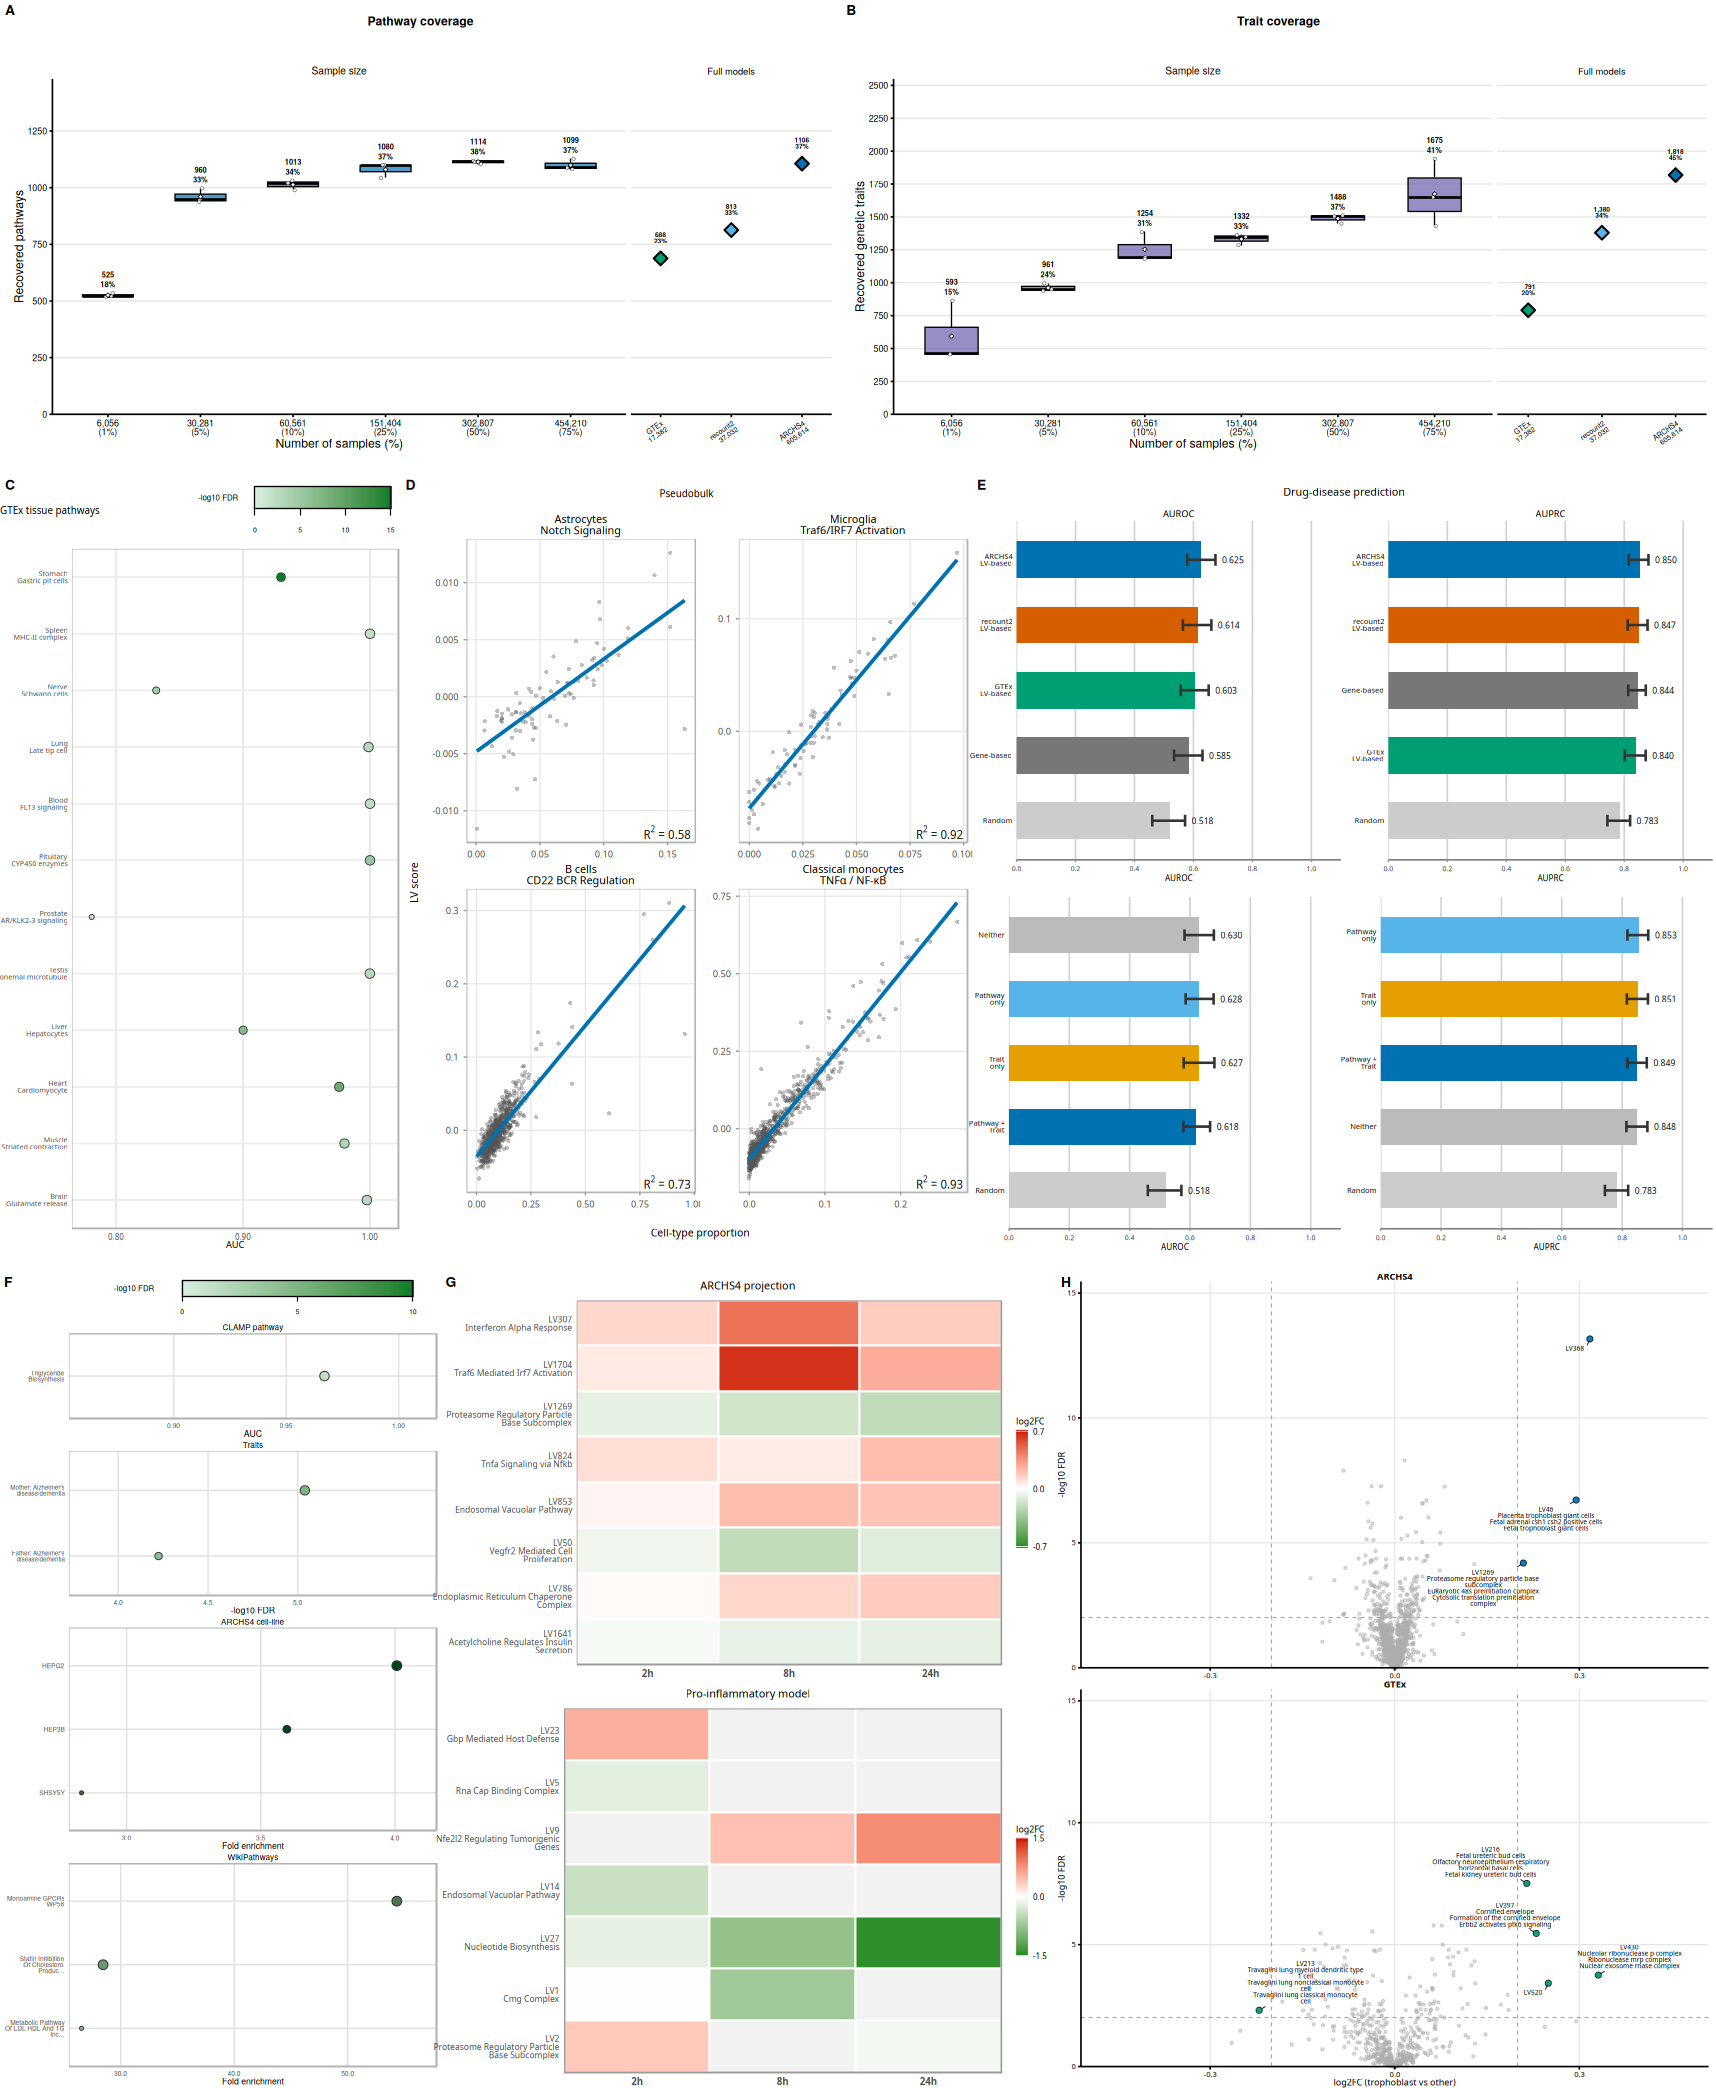

In [11]:

FIG_W <- 183
FIG_H <- 222

options(repr.plot.width = 14.3, repr.plot.height = 17.4)

# Row 1: A (pathway coverage) + B (trait coverage)
row1 <- plot_grid(
    plot_A, plot_B_composite,
    ncol = 2, rel_widths = c(1, 1.04),
    labels = c('A', 'B'),
    label_size = 8, label_fontface = 'bold', label_fontfamily = 'Helvetica'
)

# Row 2: C (tissue biology) + D (pseudobulk) + E (drug-disease)
row2 <- plot_grid(
    plot_C, plot_D, plot_F,
    ncol = 3, rel_widths = c(0.70, 1, 1.30),
    labels = c('C', 'D', 'E'),
    label_size = 8, label_fontface = 'bold', label_fontfamily = 'Helvetica'
)

# Row 3: F (LV702) + G (cytokine beta cells) + H (placenta trophoblast)
row3 <- plot_grid(
    plot_G, plot_H, plot_I,
    ncol = 3, rel_widths = c(1.0, 1.4, 1.5), align = 'h', axis = 'tb',
    labels = c('F', 'G', 'H'),
    label_size = 8, label_fontface = 'bold', label_fontfamily = 'Helvetica'
)

fig4 <- plot_grid(
    row1, ggdraw(), row2, ggdraw(), row3,
    ncol = 1,
    rel_heights = c(0.62, 0.020, 1.05, 0.025, 1.10)
)

ggsave(file.path(PANEL_DIR, 'fig4.pdf'), fig4,
       width = FIG_W, height = FIG_H, units = 'mm', device = cairo_pdf, bg = 'white')
ggsave(file.path(PANEL_DIR, 'fig4.png'), fig4,
       width = FIG_W, height = FIG_H, units = 'mm', dpi = 300, bg = 'white')
fig4

# Normalize PDF: bake cairo transforms into standard content so any viewer shows correctly
pdf_path <- file.path(PANEL_DIR, 'fig4.pdf')
tmp_path <- file.path(PANEL_DIR, 'fig4_tmp.pdf')
system2('gs', c(
    '-dBATCH', '-dNOPAUSE', '-dQUIET',
    '-sDEVICE=pdfwrite',
    '-dAutoRotatePages=/None',
    '-dCompatibilityLevel=1.4',
    paste0('-sOutputFile=', tmp_path),
    pdf_path
))
file.rename(tmp_path, pdf_path)
system(paste('gio set', shQuote(pdf_path), 'metadata::evince::rotation 0'))